# Age-DEG trends: GLU and GABA

A concise, rerunnable curation of finalized DREAM age-DEG results. Default outputs are local to this notebook; canonical RNA-seq tables are only overwritten after an explicit opt-in.

In [1]:
from pathlib import Path
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
mpl.rcParams.update({"pdf.fonttype": 42, "ps.fonttype": 42, "font.family": "Arial", "text.color": "black", "axes.labelcolor": "black", "axes.edgecolor": "black", "xtick.color": "black", "ytick.color": "black"})
sns.set_theme(style="ticks", context="paper")
PROJECT_ROOT = Path("/cndd/hex002/PsychEncode")
RNA_SEQ_ROOT = PROJECT_ROOT / "rna_seq"
BRAIN_HYDROXY_ROOT = PROJECT_ROOT / "BrainHydroxyDevelopment"
NOTEBOOK_DIR = BRAIN_HYDROXY_ROOT / "analysis_scripts" / "Differential_expressed_genes"
OUTPUT_DIR = Path(os.environ.get("AGE_DEG_OUTPUT_DIR", NOTEBOOK_DIR / "02.Cluster_DEG_trend_outputs"))
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
EXPRESSION_DIR = RNA_SEQ_ROOT 
METADATA_PATH = Path("/datasets/Public_Datasets/Dracheva_PsychEncode_development/processed/PEC_donor_LIMS_082625.csv")
GENE_ANNOTATION_PATH = BRAIN_HYDROXY_ROOT / "analysis_scripts" / "Figures" / "data" / "gencode.v37.annotation.intragenic.bed.gz"
WRITE_CANONICAL_TABLES = False
CANONICAL_OUTPUT_DIR = RNA_SEQ_ROOT
sex_palette = {"Female": "#F16090", "Male": "#61A3D7"}
celltype_palette = {"GLU": "#4faf48", "GABA": "#397fba"}
print(f"Output directory: {OUTPUT_DIR}")

Output directory: /cndd/hex002/PsychEncode/BrainHydroxyDevelopment/analysis_scripts/Differential_expressed_genes/02.Cluster_DEG_trend_outputs


## Canonical age-DEG definition and trend assignment

In [2]:
FDR_THRESHOLD = 0.05
MIN_ABS_LOG2FC = 0.5

comparison_order = [
    "infancy-earlychildhood",
    "infancy-latechildhood",
    "infancy-adolescence",
    "infancy-adulthood",
    "infancy-lateadulthood",
    "earlychildhood-latechildhood",
    "earlychildhood-adolescence",
    "earlychildhood-adulthood",
    "earlychildhood-lateadulthood",
    "latechildhood-adolescence",
    "latechildhood-adulthood",
    "latechildhood-lateadulthood",
    "adolescence-adulthood",
    "adolescence-lateadulthood",
    "adulthood-lateadulthood",
]

all_results = pd.read_csv(RNA_SEQ_ROOT / "Dream_all_results.csv")
all_logFC_raw = (
    all_results.pivot_table(
        index=["celltype", "geneID"],
        columns="comp",
        values="logFC",
    )
    .reindex(columns=comparison_order)
)
all_P = (
    all_results.pivot_table(
        index=["celltype", "geneID"],
        columns="comp",
        values="adj.P.Val",
    )
    .reindex(columns=comparison_order)
)

# A contrast contributes to trend assignment only when it passes both
# statistical significance and the minimum biologically relevant effect.
age_deg_mask = (
    all_P.lt(FDR_THRESHOLD)
    & all_logFC_raw.abs().ge(MIN_ABS_LOG2FC)
)
all_logFC = all_logFC_raw.where(age_deg_mask, 0.0)
all_logFC = all_logFC.loc[age_deg_mask.any(axis=1)].copy()


In [3]:
def same_sign(row):
    signs = np.sign(row.loc[row.ne(0)])
    return signs.nunique() <= 1

In [4]:
def trend_detection(row):
    effectful = row.loc[row.ne(0)]
    if effectful.empty:
        raise ValueError("trend_detection received a gene with no age-DEG contrast")

    # DREAM contrasts are younger minus older. Positive values therefore
    # represent age-down genes and negative values represent age-up genes.
    direction = np.sign(effectful.iloc[0])
    early_change = abs(row["infancy-earlychildhood"])
    later_change = abs(row["earlychildhood-lateadulthood"])
    early_dominant = early_change > later_change

    if direction > 0:
        return 0 if early_dominant else 1
    return 2 if early_dominant else 3


trend_labels = {
    0: "early_down",
    1: "late_down",
    2: "early_up",
    3: "late_up",
    4: "non_monotonic_or_mixed",
}

In [5]:
all_genes_FC_monotones = all_logFC.loc[all_logFC.apply(same_sign, axis=1)].copy()
all_genes_FC_monotones["trend"] = all_genes_FC_monotones.apply(trend_detection, axis=1)
all_logFC["trend"] = 4
all_logFC.loc[all_genes_FC_monotones.index, "trend"] = all_genes_FC_monotones["trend"].astype(int)
all_logFC["trend"] = all_logFC["trend"].astype(int)
gene_trend = all_logFC[["trend"]].reset_index()
gene_trend["trend"] = gene_trend["trend"].map(trend_labels)
gene_trend_qc = all_logFC[comparison_order].assign(n_effectful_contrasts=lambda x: x.ne(0).sum(axis=1), max_abs_log2FC=lambda x: x[comparison_order].abs().max(axis=1), trend_code=all_logFC["trend"], trend=all_logFC["trend"].map(trend_labels)).reset_index()
trend_counts = gene_trend.groupby(["celltype", "trend"]).size().rename("n_genes").reset_index()
definition = pd.DataFrame({"parameter": ["DREAM_FDR_threshold", "minimum_absolute_log2FC", "age_DEG_scope", "trend_4_definition"], "value": [FDR_THRESHOLD, MIN_ABS_LOG2FC, "passes both thresholds in at least one of 15 pairwise age contrasts", "effectful contrasts contain mixed directions"]})
gene_trend.to_csv(OUTPUT_DIR / "age_deg_trend_assignments.tsv", sep="\t", index=False)
gene_trend_qc.to_csv(OUTPUT_DIR / "age_deg_trend_qc.tsv", sep="\t", index=False)
trend_counts.to_csv(OUTPUT_DIR / "age_deg_trend_counts.tsv", sep="\t", index=False)
definition.to_csv(OUTPUT_DIR / "age_deg_definition.tsv", sep="\t", index=False)
if WRITE_CANONICAL_TABLES:
    gene_trend.to_csv(CANONICAL_OUTPUT_DIR / "gene_trend.csv", index=False)
    gene_trend_qc.to_csv(CANONICAL_OUTPUT_DIR / "gene_trend_qc.csv", index=False)
    definition.to_csv(CANONICAL_OUTPUT_DIR / "gene_trend_definition.tsv", sep="\t", index=False)
display(trend_counts.pivot(index="trend", columns="celltype", values="n_genes").fillna(0).astype(int))

celltype,GABA,GLU
trend,,
early_down,510,793
early_up,365,516
late_down,1348,2246
late_up,1352,2059
non_monotonic_or_mixed,49,180


## Age-DEG contrast counts

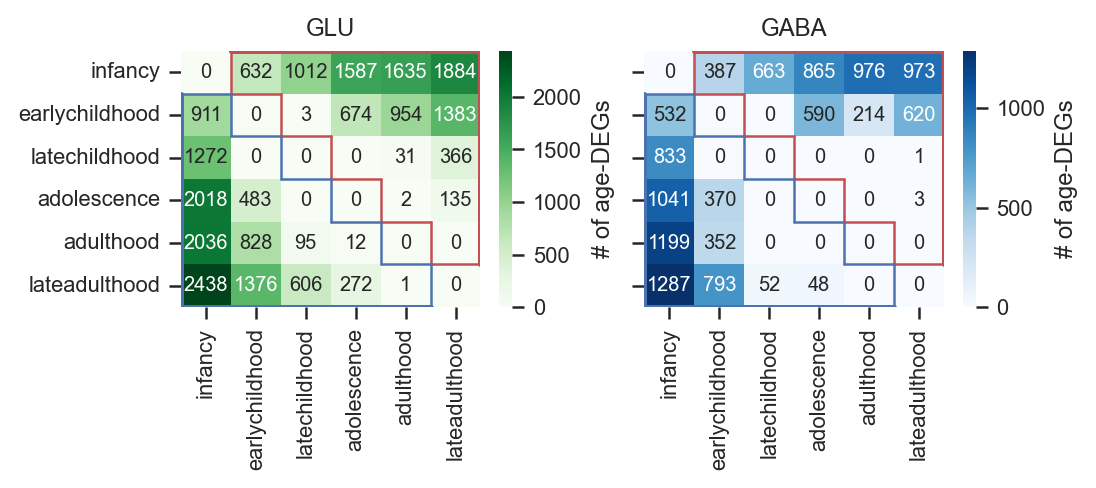

In [6]:
period_order_heng=['infancy', 'earlychildhood', 'latechildhood', 'adolescence', 'adulthood','lateadulthood']
fig,axs=plt.subplots(1,2,figsize=(6.2,2.8),dpi=180,sharey=True)

for j, celltype in enumerate(['GLU','GABA']):
    ax=axs[j]
    tmp = all_results.loc[
        all_results["celltype"].eq(celltype)
        & all_results["adj.P.Val"].lt(FDR_THRESHOLD)
        & all_results["logFC"].abs().ge(MIN_ABS_LOG2FC)
    ].copy()
    tmp['comp1_tmp']=tmp['comp'].str.split('-').str[0]
    tmp['comp2_tmp']=tmp['comp'].str.split('-').str[1]
    # tmp=tmp.reset_index().rename(columns={'index':'gene_id'}).set_index(['gene_id','comp'])
    tmp=tmp.reset_index().set_index(['index','comp'])
    tmp['comp1']=tmp['comp1_tmp']
    tmp.loc[tmp['logFC'] > 0, 'comp1'] = tmp['comp2_tmp']
    tmp['comp2']=tmp['comp2_tmp']
    tmp.loc[tmp['logFC'] > 0, 'comp2'] = tmp['comp1_tmp']
    tmp=tmp.drop(columns=['comp1_tmp','comp2_tmp'])
    tmp=tmp.groupby(['comp1','comp2']).size().to_frame('n').reset_index().pivot(index='comp1',columns='comp2',values='n')\
     .loc[period_order_heng,period_order_heng].fillna(0).astype(int)
    
    if celltype == 'GLU':
        sns.heatmap(tmp,cmap='Greens', annot=True, fmt='g',annot_kws={"fontsize":8}, cbar_kws={'label':'# of age-DEGs'},ax=ax)
    else:
        sns.heatmap(tmp,cmap='Blues', annot=True, fmt='g',annot_kws={"fontsize":8}, cbar_kws={'label':'# of age-DEGs'},ax=ax)
    ax.set_xlabel('')
    ax.set_ylabel('')
    
    for i in range(tmp.shape[0]-1):
        ax.plot([i + 1 , i + 2], [i + 1, i + 1], color='r', linewidth=1)  
        ax.plot([i + 1, i + 1 ], [i + 1, i], color='r', linewidth=1)  
    ax.plot([1 , 6], [0 , 0 ], color='r', linewidth=2)  
    ax.plot([6 , 6], [0 , 5 ], color='r', linewidth=2)  
    for i in range(tmp.shape[0]-1):
        ax.plot([i + 1, i ],[i + 1 , i + 1], color='b', linewidth=1)  
        ax.plot([i + 1, i + 1],[i + 1, i +2], color='b', linewidth=1)
    ax.plot([0 , 5], [6 , 6 ], color='b', linewidth=2)  
    ax.plot([0 , 0], [1 , 6 ], color='b', linewidth=2) 
    ax.set_title(celltype)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'age_deg_contrast_counts_heatmap.pdf', bbox_inches='tight')
# plt.savefig('/cndd/hex002/PsychEncode/Figures/ageDEGs_number_fc05.pdf',dpi=150)

## Shared GLU-vs-GABA age logFC

In [7]:
gene_meta = pd.read_csv(GENE_ANNOTATION_PATH, sep="\t", header=None, names=["chr", "start", "end", "gene_id", "strand", "feature", "gene_name", "gene_type"], index_col="gene_id")
all_results["gene_name"] = all_results["geneID"].map(gene_meta["gene_name"])
gene_cluster = all_logFC[["trend"]].rename(columns={"trend": "trend_code"}).reset_index()
gene_cluster["trend"] = gene_cluster["trend_code"].map(trend_labels)

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    from adjustText import adjust_text
except ImportError:
    def adjust_text(*args, **kwargs): return []


def plot_shared_logfc(
    results,
    genes=None,
    comp=None,
    celltypes=None,
    padj=FDR_THRESHOLD,
    min_abs_log2fc=MIN_ABS_LOG2FC,
    top_n=2,
    reverse_sign=True,
    figsize=(3.5, 3.5),
):
    genes = genes or []

    # Filter significant genes
    data = results.loc[
        results["adj.P.Val"].lt(padj)
        & results["logFC"].abs().ge(min_abs_log2fc)
    ].copy()

    if comp is not None:
        data = data.loc[data["comp"].eq(comp)]

    # Convert to age direction: positive = age-up; negative = age-down
    if reverse_sign:
        data["logFC"] = -data["logFC"]

    # Use specified cell types or detect them
    if celltypes is None:
        celltypes = list(data["celltype"].dropna().unique())

    if len(celltypes) != 2:
        raise ValueError(
            f"Exactly two cell types are required; found {celltypes}"
        )

    x_ct, y_ct = celltypes
    data = data.loc[data["celltype"].isin(celltypes)]

    # Retain genes significant in both cell types
    index_cols = ["comp", "gene_name"] if comp is None else ["gene_name"]

    quad_df = (
        data.pivot_table(
            index=index_cols,
            columns="celltype",
            values="logFC",
            aggfunc="first",
        )
        .dropna(subset=celltypes)
        .reset_index()
    )
    quad_df.columns.name = None

    # Classify direction
    conditions = [
        (quad_df[x_ct] > 0) & (quad_df[y_ct] > 0),
        (quad_df[x_ct] > 0) & (quad_df[y_ct] < 0),
        (quad_df[x_ct] < 0) & (quad_df[y_ct] > 0),
        (quad_df[x_ct] < 0) & (quad_df[y_ct] < 0),
    ]
    labels = ["Up–Up", "Up–Down", "Down–Up", "Down–Down"]

    quad_df["quadrant"] = np.select(
        conditions, labels, default="Unclassified"
    )
    quad_df["max_abs_logFC"] = quad_df[[x_ct, y_ct]].abs().max(axis=1)
    quad_df["divergence"] = (quad_df[x_ct] - quad_df[y_ct]).abs()
    # Select the strongest divergent genes in each quadrant
    divergent = (
        quad_df.loc[quad_df["quadrant"].isin(["Up–Down", "Down–Up"])]
        .sort_values("divergence", ascending=False)
        .drop_duplicates(subset="gene_name")  # strongest comparison per gene
        .groupby("quadrant", sort=False)
        .head(top_n)
    )

    # Select the most divergent comparison for each requested gene
    forced = (
        quad_df.loc[quad_df["gene_name"].isin(genes)]
        .sort_values("divergence", ascending=False)
        .drop_duplicates(subset="gene_name")
    )

    label_df = (
        pd.concat([divergent, forced], ignore_index=True)
        .sort_values("divergence", ascending=False)
        .drop_duplicates(subset="gene_name")
    )

    # Plot
    fig, ax = plt.subplots(figsize=figsize)

    concordant = quad_df["quadrant"].isin(["Up–Up", "Down–Down"])

    ax.scatter(
        quad_df.loc[concordant, x_ct],
        quad_df.loc[concordant, y_ct],
        s=8,
        color="#C7C7C7",
        alpha=0.5,
        edgecolors="none",
        label="Concordant",
        zorder=1,
        rasterized=True
    )

    ax.scatter(
        quad_df.loc[~concordant, x_ct],
        quad_df.loc[~concordant, y_ct],
        s=14,
        color="#1F77B4",
        alpha=1,
        edgecolors="none",
        label="Divergent",
        zorder=2,
    )
    ax.scatter(
        label_df[x_ct],
        label_df[y_ct],
        s=14,
        color="#D62728",
        zorder=4,
    )

    texts = [
        ax.text(
            row[x_ct],
            row[y_ct],
            row["gene_name"],
            fontsize=7,
            color="#D62728",
            ha="center",
            va="center",
            zorder=5,
        )
        for _, row in label_df.iterrows()
    ]

    adjust_text(
        texts,
        ax=ax,
        x=label_df[x_ct].to_numpy(),
        y=label_df[y_ct].to_numpy(),
        expand=(1.2, 1.3),
        force_text=(0.4, 0.6),
        force_points=(0.3, 0.5),
        arrowprops=dict(
            arrowstyle="->",
            color="#999999",
            lw=0.6,
        ),
    )

    ax.axhline(0, color="black", ls="--", lw=0.6)
    ax.axvline(0, color="black", ls="--", lw=0.6)
    ax.set(
        xlabel=f"{x_ct} age logFC",
        ylabel=f"{y_ct} age logFC",
        title=comp or "Shared significant genes",
    )
    ax.legend(frameon=False, fontsize=7)
    ax.grid(color="#EEEEEE", lw=0.5)
    ax.set_aspect("equal", adjustable="datalim")

    fig.tight_layout()
    return fig, ax, quad_df

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


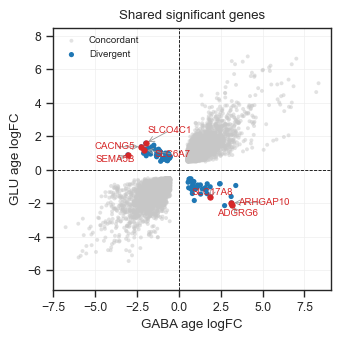

In [9]:
fig, ax, quad_df = plot_shared_logfc(
    all_results,
    genes=[ "SLC6A7"],
    # comp="infancy-earlychildhood",
    celltypes=["GABA", "GLU"],
    padj=FDR_THRESHOLD,
    min_abs_log2fc=MIN_ABS_LOG2FC,
    top_n=3,
)
# quad_df.to_csv(OUTPUT_DIR / 'age_deg_shared_logFC.tsv', sep='\t', index=False)
# plt.savefig(OUTPUT_DIR / 'age_deg_shared_logFC.pdf', dpi=300, bbox_inches='tight')
plt.show()

## Expression trajectories by inherited trend calls

In [10]:
from scipy.interpolate import UnivariateSpline

def minmax_01_df(df):
    row_min, row_max = df.min(axis=1), df.max(axis=1)
    return df.sub(row_min, axis=0).div((row_max - row_min).replace(0, np.nan), axis=0).fillna(0)

def fit_bspline_ridge(x, y, x_grid, **kwargs):
    # Aggregate repeated ages, then smooth the per-sample class mean.
    frame = pd.DataFrame({"x": np.asarray(x, float), "y": np.asarray(y, float)}).groupby("x", as_index=False)["y"].mean()
    if len(frame) < 4:
        return np.interp(x_grid, frame["x"], frame["y"])
    spline = UnivariateSpline(frame["x"], frame["y"], k=min(3, len(frame) - 1), s=len(frame) * 0.01)
    return spline(x_grid)

In [11]:
def split_transient_up_down(
    expr_01,
    trend_sub,
    sample_ages,
    transient_label="non_monotonic_or_mixed",
):
    # Split inherited nonmonotonic/mixed genes into two descriptive
    # expression-trajectory groups.
    transient_genes = trend_sub.loc[
        trend_sub.eq(transient_label)
    ].index
    transient_genes = expr_01.index.intersection(transient_genes)
    d = expr_01.loc[transient_genes]

    early_samples = sample_ages.loc[sample_ages.le(2)].index
    middle_samples = sample_ages.loc[
        sample_ages.gt(2) & sample_ages.le(12)
    ].index
    late_samples = sample_ages.loc[sample_ages.gt(12)].index

    early_samples = d.columns.intersection(early_samples)
    middle_samples = d.columns.intersection(middle_samples)
    late_samples = d.columns.intersection(late_samples)

    early_mean = d[early_samples].mean(axis=1)
    middle_mean = d[middle_samples].mean(axis=1)
    late_mean = d[late_samples].mean(axis=1)
    edge_mean = pd.concat([early_mean, late_mean], axis=1).mean(axis=1)
    delta = middle_mean - edge_mean

    transient_split = pd.Series(
        index=d.index, dtype="object", name="transient_subclass"
    )
    transient_split.loc[delta.ge(0)] = "transient_up"
    transient_split.loc[delta.lt(0)] = "transient_down"
    return transient_split, delta


In [12]:
metafile = pd.read_csv(METADATA_PATH, index_col=0)

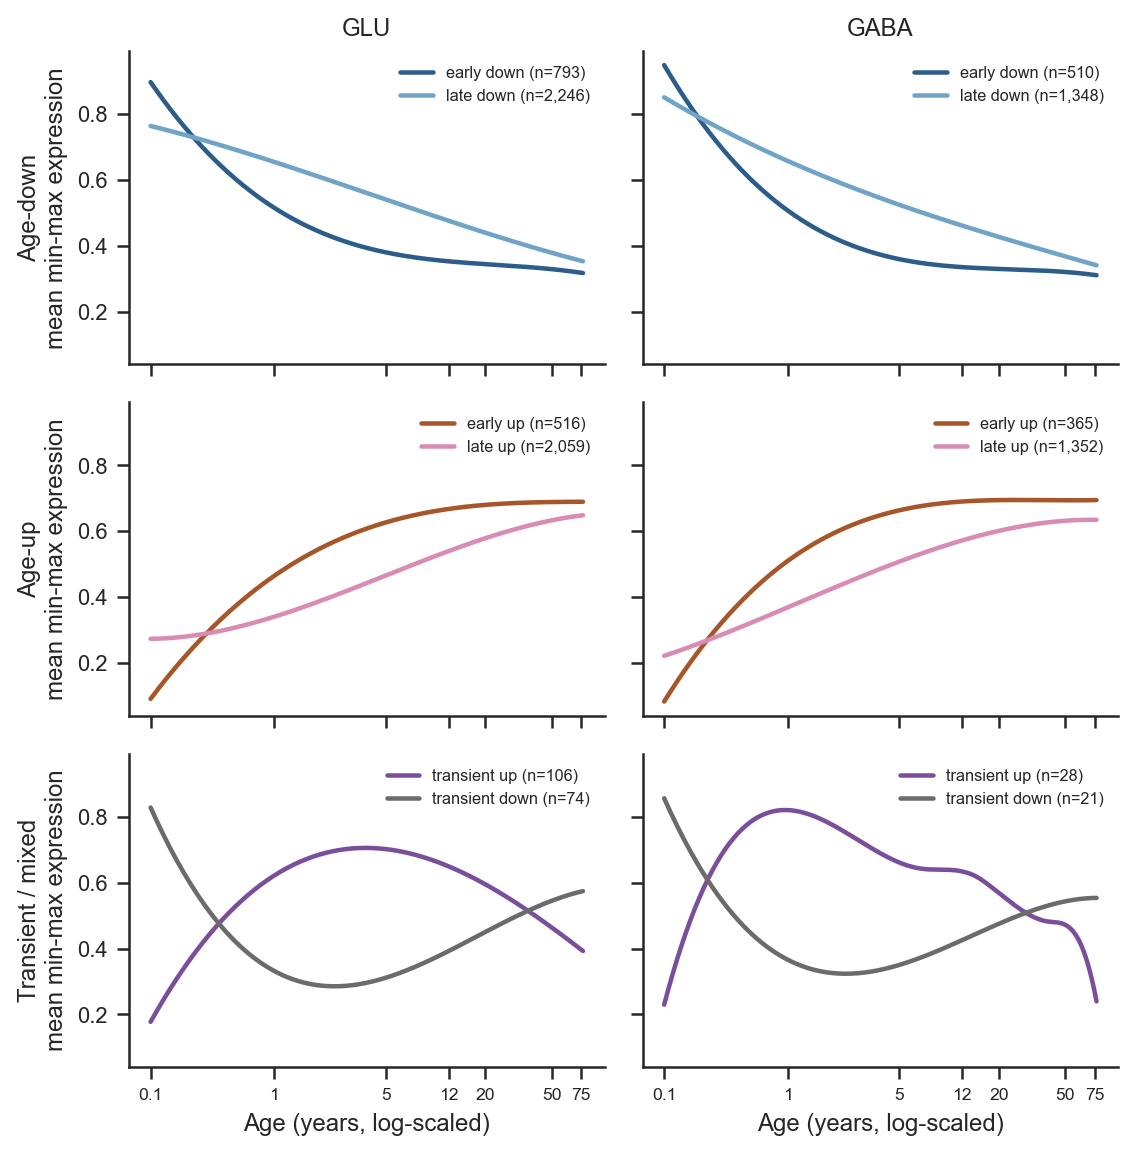

In [13]:
trajectory_data = {}
for celltype in ["GLU", "GABA"]:
    expr = pd.read_csv(EXPRESSION_DIR / f"{celltype}_DE_Dream.csv", index_col=0)
    expr = minmax_01_df(expr)
    sample_ids = expr.columns.intersection(metafile.index)
    expr = expr.loc[:, sample_ids]
    ages = metafile.loc[sample_ids, "age"].astype(float).sort_values()
    expr = expr.loc[:, ages.index]
    trends = gene_cluster.loc[gene_cluster["celltype"].eq(celltype), ["geneID", "trend"]].drop_duplicates("geneID").set_index("geneID")["trend"]
    common = expr.index.intersection(trends.index)
    expr, trends = expr.loc[common], trends.loc[common]
    transient, _ = split_transient_up_down(expr, trends, ages)
    groups = trends.copy()
    groups.loc[transient.index] = transient
    trajectory_data[celltype] = (expr, ages, groups)

rows = [("Age-down", ["early_down", "late_down"], ["#2C5C8A", "#6FA3C8"]), ("Age-up", ["early_up", "late_up"], ["#A65628", "#D98CB3"]), ("Transient / mixed", ["transient_up", "transient_down"], ["#7A4E9A", "#6B6B6B"])]
fig, axes = plt.subplots(3, 2, figsize=(6.4, 6.5), sharex=True, sharey=True, dpi=180)
trajectory_counts = []
for col, celltype in enumerate(["GLU", "GABA"]):
    expr, ages, groups = trajectory_data[celltype]
    for row, (title, labels, colors) in enumerate(rows):
        ax = axes[row, col]
        for label, color in zip(labels, colors):
            genes = groups.index[groups.eq(label)]
            trajectory_counts.append({"celltype": celltype, "subclass": label, "n_genes": len(genes)})
            if len(genes):
                average = expr.loc[genes].mean(axis=0)
                x = np.log10(ages.to_numpy() + .1)
                grid = np.linspace(x.min(), x.max(), 200)
                y = fit_bspline_ridge(x, average.to_numpy(), grid, n_knots=6, degree=3, alpha=1e-2)
                ax.plot(grid, y, color=color, lw=1.8, label=f"{label.replace('_', ' ')} (n={len(genes):,})")
        ax.set_title(celltype if row == 0 else "")
        if col == 0: ax.set_ylabel(f"{title}\nmean min-max expression")
        if row == 2:
            vals = np.array([.1, 1, 5, 12, 20, 50, 75])
            ax.set_xticks(np.log10(vals + .1)); ax.set_xticklabels(["0.1", "1", "5", "12", "20", "50", "75"], fontsize=7)
            ax.set_xlabel("Age (years, log-scaled)")
        ax.legend(frameon=False, fontsize=6.5); sns.despine(ax=ax)
fig.tight_layout()
trajectory_counts = pd.DataFrame(trajectory_counts)
# fig.savefig(OUTPUT_DIR / "age_deg_expression_trajectory_summary.pdf", bbox_inches="tight")
plt.show()

## GAM examples: DRAXIN, KCNG1, MLXIPL, PDGFRB, SERTAD4, and TMEM44

In [22]:
GABA_lcpm = pd.read_csv(EXPRESSION_DIR / "GABA_DE_Dream.csv", index_col=0)
GABA_lcpm = GABA_lcpm.loc[GABA_lcpm.index.isin(gene_meta.index)]

GLU_lcpm = pd.read_csv(EXPRESSION_DIR / "GLU_DE_Dream.csv", index_col=0)
GLU_lcpm = GLU_lcpm.loc[GLU_lcpm.index.isin(gene_meta.index)]

genedict_nametoid = dict(zip(gene_meta.gene_name, gene_meta.index))


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pygam import LinearGAM, s
from matplotlib.lines import Line2D

genes = ["DRAXIN", "KCNG1", "MLXIPL", "PDGFRB", "SERTAD4","TMEM44"]

age_offset = 0.1
n_splines = 8
lam = 0.8
n_grid_pts = 300

celltypes = ["GLU", "GABA"]

# Optional display names
celltype_label = {
    "GLU": "Glu",
    "GABA": "MGE-GABA",
}

sex_marker = {
    "M": "o",
    "F": "X",
}

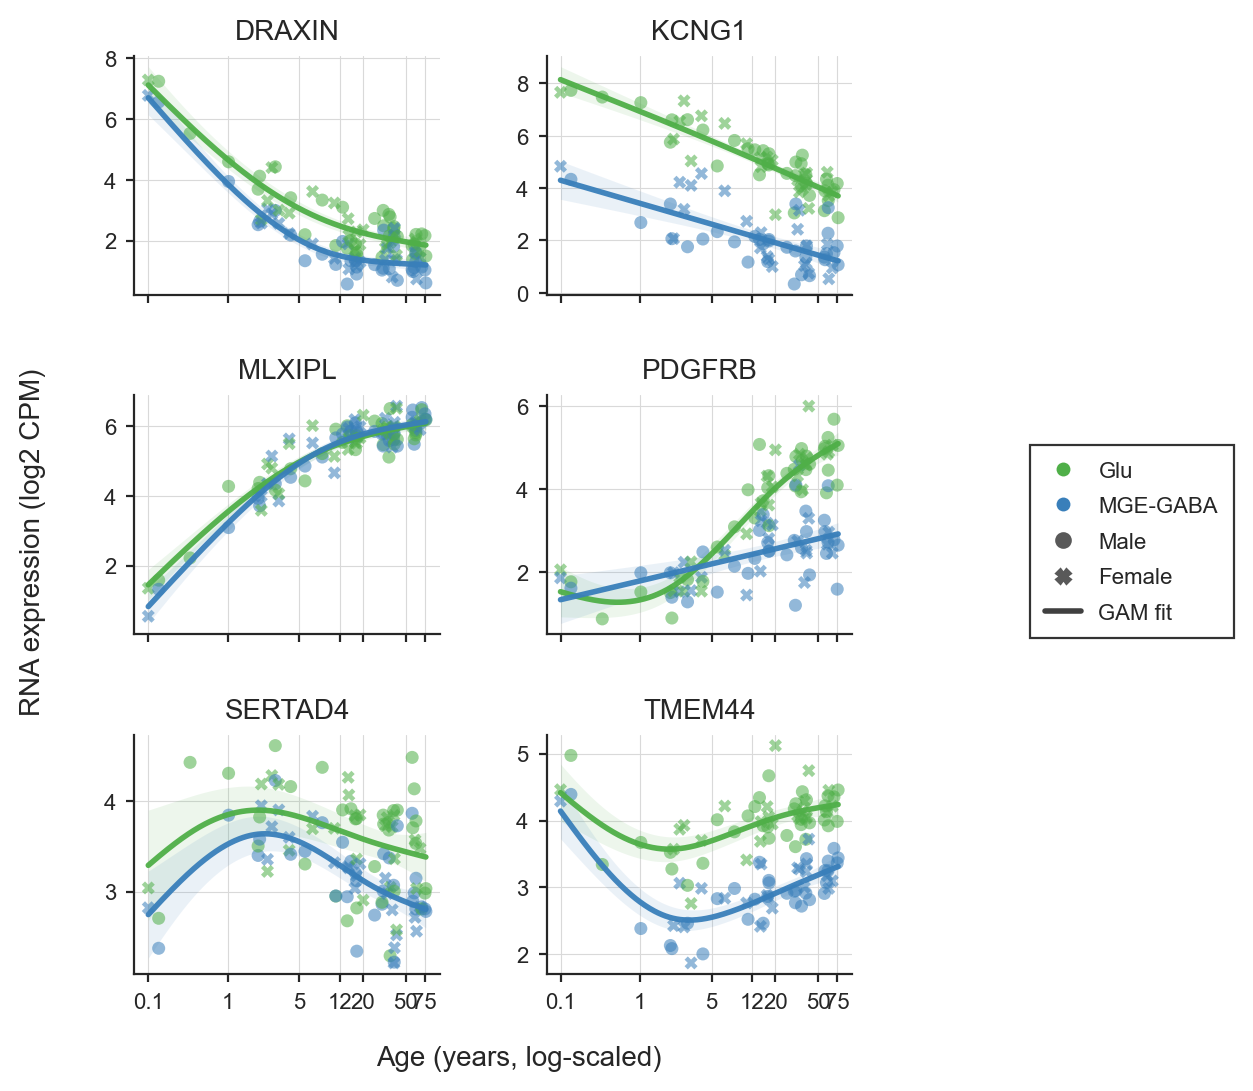

In [24]:
# -----------------------------
# Figure: 3 rows x 2 columns
# -----------------------------
fig, axes = plt.subplots(
    3,
    2,
    figsize=(5.2, 5.4),
    dpi=200,
    sharex=True,
    constrained_layout=False,  # important when using outside legend
)

axes = axes.ravel()
gene_axes = axes[:len(genes)]


for ax, gene in zip(gene_axes, genes):

    gene_id = genedict_nametoid.get(gene)

    if gene_id is None:
        print(f"Gene {gene} not found in genedict_nametoid.")
        ax.set_visible(False)
        continue

    plot_dfs = []

    for celltype, expr_df in {
        "GLU": GLU_lcpm,
        "GABA": GABA_lcpm,
    }.items():

        if gene_id not in expr_df.index:
            print(f"Gene {gene} / {gene_id} not found in {celltype}_lcpm.")
            continue

        expr = expr_df.loc[gene_id].copy()

        if isinstance(expr.index, pd.MultiIndex):
            sample_ids = expr.index.get_level_values(0)
        else:
            sample_ids = expr.index

        tmp = pd.DataFrame({
            "sample": sample_ids,
            "expr": expr.values.astype(float),
            "celltype": celltype,
        })

        tmp = tmp[tmp["sample"].isin(metafile.index)].copy()
        tmp["age"] = tmp["sample"].map(metafile["age"]).astype(float)

        if "sex" in metafile.columns:
            tmp["sex"] = tmp["sample"].map(metafile["sex"]).astype(str)
        else:
            tmp["sex"] = "NA"

        tmp = tmp.dropna(subset=["expr", "age"])
        tmp["log10_age"] = np.log10(tmp["age"] + age_offset)

        plot_dfs.append(tmp)

    if len(plot_dfs) == 0:
        ax.set_visible(False)
        continue

    gene_df = pd.concat(plot_dfs, ignore_index=True)
    gene_df = gene_df.sort_values("log10_age")

    sns.scatterplot(
        data=gene_df,
        x="log10_age",
        y="expr",
        hue="celltype",
        style="sex",
        palette=celltype_palette,
        markers={
            "Male": "o",
            "Female": "X",
        },
        s=22,
        alpha=0.55,
        linewidth=0,
        edgecolor=None,
        ax=ax,
        legend=False,
        rasterized=True,
        zorder=2,
    )

    for celltype in celltypes:

        df = gene_df[gene_df["celltype"] == celltype].copy()

        if df.shape[0] < 5:
            print(f"Skipping GAM for {gene} {celltype}: fewer than 5 samples.")
            continue

        x = df["log10_age"].values
        y = df["expr"].values

        order = np.argsort(x)
        x = x[order]
        y = y[order]

        try:
            X = x.reshape(-1, 1)

            gam = LinearGAM(
                s(0, n_splines=n_splines, spline_order=3),
                fit_intercept=True,
            )

            gam.gridsearch(
                X,
                y,
                lam= np.logspace(0, 5, 25),
                progress=False,
            )

            x_grid = np.linspace(x.min(), x.max(), n_grid_pts).reshape(-1, 1)
            y_grid = gam.predict(x_grid)
            ci = gam.confidence_intervals(x_grid, width=0.95)

            color = celltype_palette[celltype]

            ax.fill_between(
                x_grid.ravel(),
                ci[:, 0],
                ci[:, 1],
                color=color,
                alpha=0.10,
                linewidth=0,
                zorder=1,
            )

            ax.plot(
                x_grid.ravel(),
                y_grid,
                color=color,
                linewidth=2.0,
                alpha=0.95,
                zorder=3,
            )

        except Exception as e:
            print(f"GAM failed for {gene} {celltype}: {e}")

    ax.set_title(
        f"{gene}",
        fontsize=10,
        # pad=4,
    )

    ax.grid(axis="both", linewidth=0.4, color="0.85")

    ax.set_ylabel("")
    ax.set_xlabel("")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)

    ax.tick_params(axis="both", labelsize=8, width=0.8, length=3)


# -----------------------------
# X-axis: real age labels on log10(age + 0.1) scale
# -----------------------------
age_tick_values = np.array([0.1, 1, 5, 12, 20, 50, 75], dtype=float)
age_tick_pos = np.log10(age_tick_values + age_offset)
age_tick_labels = ["0.1", "1", "5", "12", "20", "50", "75"]

all_age_values = []

for expr_df in [GLU_lcpm, GABA_lcpm]:
    if isinstance(expr_df.columns, pd.MultiIndex):
        sample_ids = expr_df.columns.get_level_values(0)
    else:
        sample_ids = expr_df.columns

    sample_ids = pd.Index(sample_ids).intersection(metafile.index)
    all_age_values.extend(metafile.loc[sample_ids, "age"].astype(float).values)

all_age_values = np.asarray(all_age_values, dtype=float)

x_min = np.log10(np.nanmin(all_age_values) + age_offset)
x_max = np.log10(np.nanmax(all_age_values) + age_offset)

valid_ticks = (age_tick_pos >= x_min) & (age_tick_pos <= x_max)

for ax in gene_axes:
    if not ax.get_visible():
        continue

    ax.set_xticks(age_tick_pos[valid_ticks])
    ax.set_xticklabels(
        np.array(age_tick_labels)[valid_ticks],
        fontsize=8,
    )


# -----------------------------
# Legend outside regular plot
# -----------------------------
celltype_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="None",
        markersize=5,
        markerfacecolor=celltype_palette["GLU"],
        markeredgecolor="none",
        label="Glu",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="None",
        markersize=5,
        markerfacecolor=celltype_palette["GABA"],
        markeredgecolor="none",
        label="MGE-GABA",
    ),
]

sex_handles = [
    Line2D(
        [0],
        [0],
        marker=sex_marker["M"],
        color="0.35",
        linestyle="None",
        markersize=5,
        label="Male",
    ),
    Line2D(
        [0],
        [0],
        marker=sex_marker["F"],
        color="0.35",
        linestyle="None",
        markersize=5,
        label="Female",
    ),
]

line_handles = [
    Line2D(
        [0],
        [0],
        color="0.25",
        linewidth=2,
        label="GAM fit",
    ),
]

fig.legend(
    handles=celltype_handles + sex_handles + line_handles,
    frameon=True,
    fancybox=False,
    edgecolor="black",
    fontsize=8,
    loc="center left",
    bbox_to_anchor=(0.98, 0.5),
    handlelength=1.6,
    borderpad=0.7,
    labelspacing=0.7,
)


# Shared labels
fig.supxlabel("Age (years, log-scaled)", fontsize=10)
fig.supylabel("RNA expression (log2 CPM)", fontsize=10)

# Leave room on right for outside legend
fig.subplots_adjust(
    left=0.13,
    right=0.82,
    bottom=0.10,
    top=0.95,
    wspace=0.35,
    hspace=0.42,
)

# Save
plt.savefig(OUTPUT_DIR / "age_deg_examples_GAM_3x2.pdf", bbox_inches="tight")

plt.show()